# 👥 Segmentação de Clientes — Análise RFM + K-Means

**RFM** é uma técnica clássica de CRM que classifica clientes em 3 dimensões:

| Dimensão | Pergunta |
|---|---|
| **R**ecência | Há quantos dias o cliente comprou pela última vez? |
| **F**requência | Quantas vezes ele comprou? |
| **M**onetário | Quanto ele gastou no total? |

Combinamos as 3 dimensões com **K-Means** para descobrir segmentos de negócio automaticamente.


In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

from src.load_data import load_raw, build_master

BG = '#F8FAFC'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.35,
})

dfs = load_raw()
df  = build_master(dfs)
print(f'✅ {df.shape[0]:,} linhas carregadas')

✅ 110,189 linhas carregadas


## 1. Calcular métricas RFM por cliente

In [3]:
snapshot = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby('customer_unique_id')
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (snapshot - x.max()).days),
        frequency = ('order_id', 'nunique'),
        monetary  = ('payment_value', 'sum'),
    )
    .reset_index()
)

print(rfm.describe().round(2))

        recency  frequency   monetary
count  93350.00   93350.00   93350.00
mean     237.95       1.03     211.83
std      152.59       0.21     642.19
min        1.00       1.00       0.00
25%      114.00       1.00      63.74
50%      219.00       1.00     112.95
75%      346.00       1.00     201.74
max      714.00      15.00  109312.64


## 2. Escolher número ideal de clusters — Elbow + Silhouette

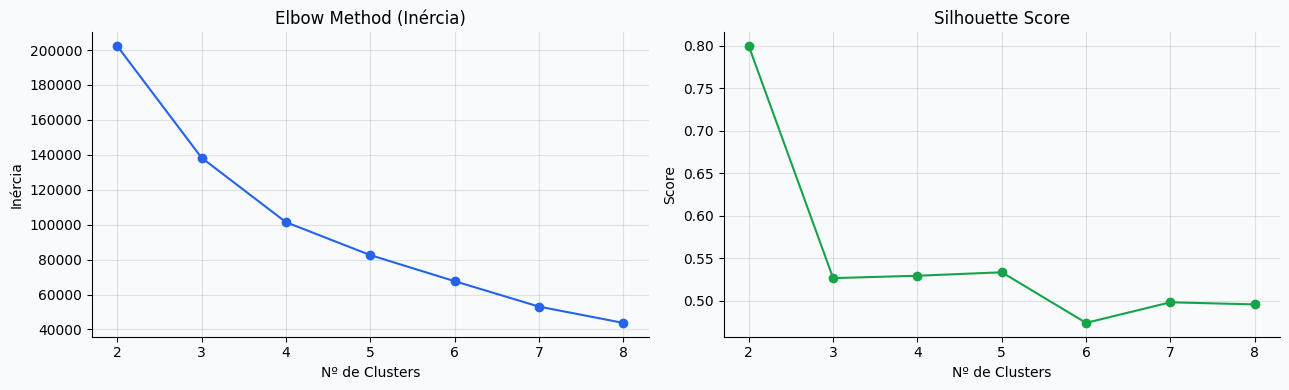

In [4]:
scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, 'o-', color='#2563EB')
axes[0].set_title('Elbow Method (Inércia)')
axes[0].set_xlabel('Nº de Clusters')
axes[0].set_ylabel('Inércia')

axes[1].plot(K_range, silhouettes, 'o-', color='#16A34A')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Nº de Clusters')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('../data/processed/fig_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Aplicar K-Means com k=4

In [6]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# Perfil médio de cada cluster
profile = (
    rfm.groupby('cluster')
    .agg(clientes=('customer_unique_id','count'),
         recency_med=('recency','median'),
         freq_med=('frequency','median'),
         monetary_med=('monetary','median'))
    .reset_index()
)

# Nomear segmentos com base no perfil
# Lógica: baixa recência + alta frequência + alto monetary = Champions
def label_segment(row):
    r, f, m = row['recency_med'], row['freq_med'], row['monetary_med']
    if r < 100 and f >= 1 and m > 200:
        return 'Champions'
    elif r < 200 and m > 100:
        return 'Loyal'
    elif r > 300:
        return 'Lost'
    else:
        return 'At Risk'

profile['segment'] = profile.apply(label_segment, axis=1)
seg_map = dict(zip(profile['cluster'], profile['segment']))
rfm['segment'] = rfm['cluster'].map(seg_map)

print(profile[['segment','clientes','recency_med','freq_med','monetary_med']].to_string(index=False))

segment  clientes  recency_med  freq_med  monetary_med
  Loyal     52140        129.0       1.0        111.32
  Loyal      2798        199.0       2.0        250.87
   Lost     38391        375.0       1.0        107.87
At Risk        21        231.0       1.0      19342.26


## 4. Visualizar segmentos

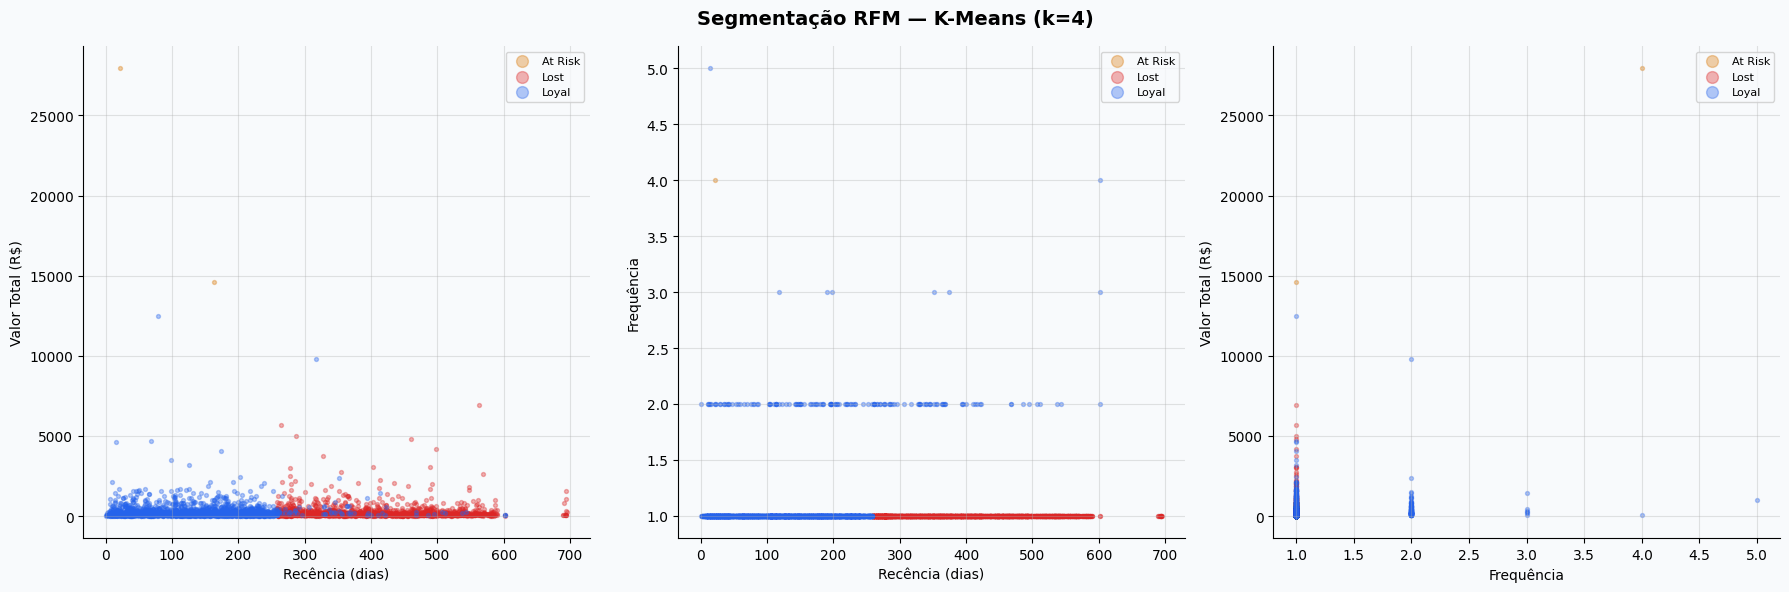

In [7]:
SEG_COLORS = {
    'Champions': '#16A34A',
    'Loyal':     '#2563EB',
    'At Risk':   '#D97706',
    'Lost':      '#DC2626',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segmentação RFM — K-Means (k=4)', fontsize=14, fontweight='bold')

pairs = [('recency','monetary'), ('recency','frequency'), ('frequency','monetary')]
labels_pt = {'recency':'Recência (dias)', 'frequency':'Frequência', 'monetary':'Valor Total (R$)'}

sample = rfm.sample(min(5000, len(rfm)), random_state=42)

for ax, (x, y) in zip(axes, pairs):
    for seg, grp in sample.groupby('segment'):
        ax.scatter(grp[x], grp[y], alpha=0.35, s=8,
                   color=SEG_COLORS.get(seg, 'gray'), label=seg)
    ax.set_xlabel(labels_pt[x])
    ax.set_ylabel(labels_pt[y])
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.savefig('../data/processed/fig_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

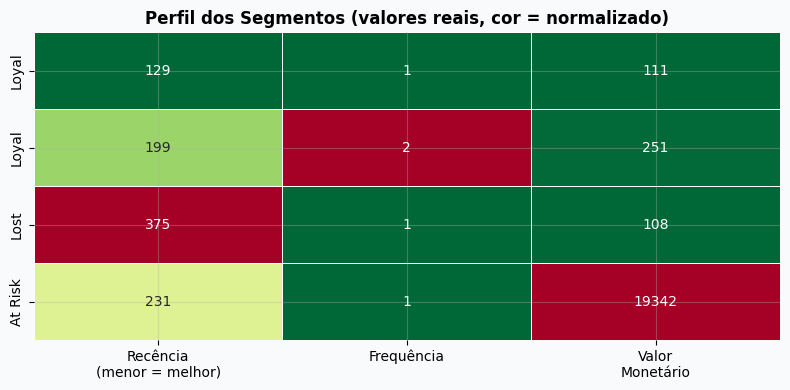

In [6]:
# Heatmap de perfil normalizado
heat_data = profile.set_index('segment')[['recency_med','freq_med','monetary_med']]
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())
heat_norm.columns = ['Recência\n(menor = melhor)','Frequência','Valor\nMonetário']

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_norm, annot=heat_data.round(0), fmt='.0f',
            cmap='RdYlGn_r', ax=ax, linewidths=0.5, cbar=False)
ax.set_title('Perfil dos Segmentos (valores reais, cor = normalizado)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../data/processed/fig_rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

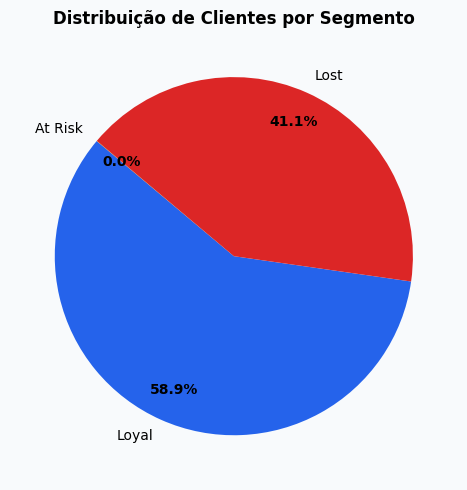

In [7]:
# Pizza de distribuição de clientes
dist = rfm['segment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
colors  = [SEG_COLORS[s] for s in dist.index]
wedges, texts, autotexts = ax.pie(
    dist.values, labels=dist.index, autopct='%1.1f%%',
    colors=colors, startangle=140, pctdistance=0.82
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Distribuição de Clientes por Segmento', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/fig_rfm_pizza.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Exportar para Power BI

In [8]:
from pathlib import Path
rfm.to_csv('../data/processed/olist_rfm.csv', index=False)
print('✅ olist_rfm.csv salvo em data/processed/')
print(rfm.groupby('segment').agg(
    clientes=('customer_unique_id','count'),
    receita_total=('monetary','sum')
).round(2))

✅ olist_rfm.csv salvo em data/processed/
         clientes  receita_total
segment                         
At Risk        21      573345.76
Lost        38391     7648858.19
Loyal       54938    11552577.57


In [9]:
rfm.to_csv('../data/processed/olist_rfm.csv', index=False, decimal=',', sep=';')
print('✅ olist_rfm.csv salvo com separador ponto e vírgula')

✅ olist_rfm.csv salvo com separador ponto e vírgula
